# **Image Filtering in Spatial and Frequency Domains (Part II)**
    
This lab introduces you to image filtering techniques, starting from basic convolution operations 
and progressing through spatial and frequency domain filtering. 

By the end of this lab, students will be able to:
- Implement and understand 2D convolution.
- Apply and analyze different types of noise.
- Perform spatial domain filtering (linear and nonlinear).
- Validate results using OpenCV functions and compute quantitative metrics.
- Perform frequency domain filtering using the Fourier Transform.
- Compare spatial and frequency domain filtering in terms of results and efficiency.


## **Lab Structure**
This lab is divided into two main parts:

- **Part I: Spatial Filtering** → You will explore **spatial domain techniques**, focusing on convolution-based filtering, noise reduction, and edge detection.
- **Part II: Frequency Filtering** → You will study **Fourier-based filtering**, transforming images into the frequency domain to apply the same filtering operations performed in the spatial domain.

Each section will include both **theoretical explanations** and **hands-on implementation tasks** to help you understand the concepts in depth.


---



### Understanding the libraries used
Before starting the lab, provide a brief definition of the following libraries and their role in image processing:

- **OpenCV**: Open Source Computer Vision Library, primarily used for image and video processing tasks such as geometric transformations, filtering, and morphological operations.
  It is used in this lab to load images, convert them to grayscale, apply spatial filters, and validate some results.

- **NumPy**: A fundamental package for numerical computing in Python, providing support for arrays, matrices, and mathematical functions used in image processing.
  It is used here to represent images as arrays and to compute the Fourier Transform, masks, kernels, and numerical comparisons.

- **Matplotlib**: A plotting library for Python that enables visualization of images, histograms, and transformations applied to images.
  It is used in this lab to display the original images, spectra, masks, and reconstructed results clearly.

If not installed, you can install them using:

`pip install opencv-python numpy matplotlib`


In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Manipulation 2: Frequency Domain Filtering

This section explores **frequency domain filtering techniques** and their impact on image processing. Frequency space provides insights into how an image is composed of different frequency components. It covers:


1. **Discrete Fourier Transform (DFT):** Converts an image from the spatial domain to the frequency domain using the Fast Fourier Transfrom algorithm (FFT).
2. **Filtering in Frequency Domain:**
    
    - **Low-pass filtering:** Retains smooth structures, removes high-frequency noise.
    - **High-pass filtering:** Enhances fine details and edges while suppressing smooth variations.



#### What will you learn?
- How an image is represented in the frequency domain using the **Fourier Transform**.
- How different frequency components contribute to image structure.
- The effects of **low-pass and high-pass filtering** on image sharpness and noise removal.



---

## Task 1: Frequency domain filtering using the fourier transform

#### **T1.1: Convert an image to the frequency domain**

 - You will work on different images such as (`boat`, `cameraman`, `leaning`) or any image of your preference and convert it to grayscale if necessary.
 - Apply fft2() to obtain the frequency representation
 - Use fftshift() to center the low-frequency components
 - Compute and display:
   - The original grayscale image
   - Magnitude spectrum
   - Phase spectrum of the transformed image


**Analysis:**

- Scale the **magnitude spectrum** using a **log scale** to enhance visibility.

$$
M_{\log} = \log(1 + |F(u, v)|)
$$

Where:
- $ F(u, v) $ is the **Fourier Transform** of the image.
- $ |F(u, v)| $ represents the **magnitude spectrum** (absolute value of the complex FFT output).
- The **log function** improves visualization by compressing high values.


- **What do you observe?**  
  - How are high and low frequencies distributed?
  - How does the magnitude spectrum vary across different images?
  - Examine the magnitude spectrum of each image and try to interpret it:
    - Identify which frequency components correspond to specific spatial features in the image (e.g., horizontal or vertical edges).
    - How do structured patterns (such as textures or in case there is repetitive elements) appear in the frequency domain?


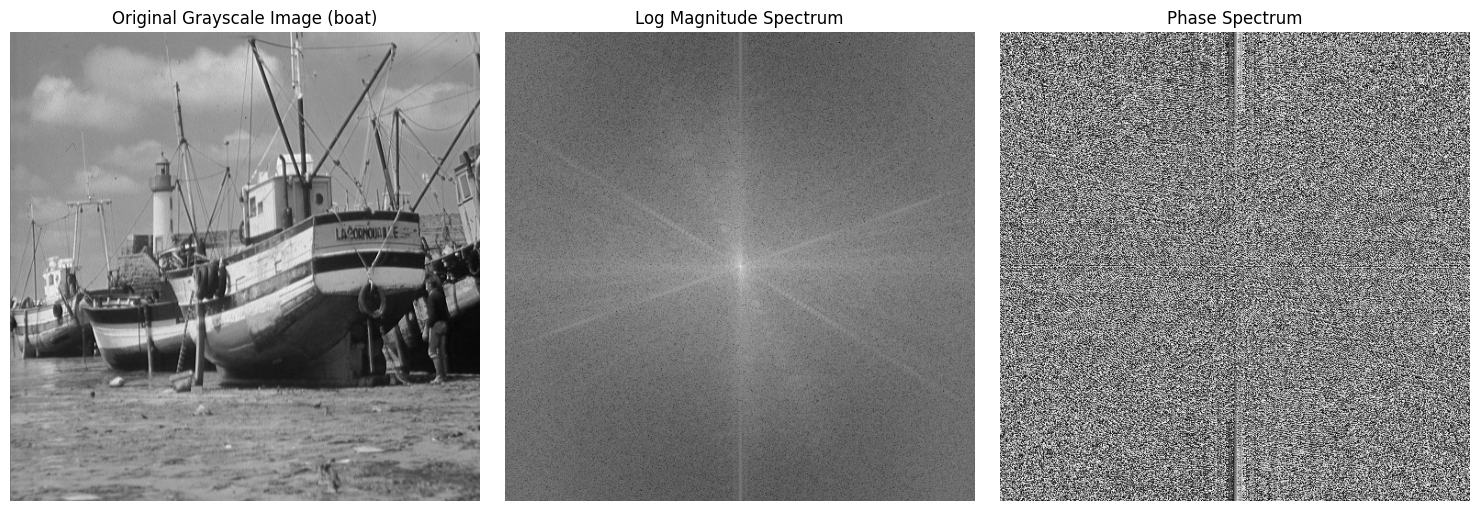

Ellipsis

In [2]:

# Your code here.
import os
from pathlib import Path


def load_gray_image(name):
    candidates = [
        Path('images') / f'{name}.png',
        Path('images') / f'{name}.jpg',
        Path('images') / f'{name}.jpeg',
        Path('images') / f'{name}.bmp',
        Path('/mnt/data/images') / f'{name}.png',
        Path('/mnt/data/images') / f'{name}.jpg',
        Path('/mnt/data/images') / f'{name}.jpeg',
        Path('/mnt/data/images') / f'{name}.bmp',
    ]

    for path in candidates:
        if path.exists():
            image = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
            if image is not None:
                return image

    raise FileNotFoundError(f'Image {name} was not found in the expected folders.')


image_name = 'boat'
img = load_gray_image(image_name)

F = np.fft.fft2(img)
F_shift = np.fft.fftshift(F)

magnitude_spectrum = np.abs(F_shift)
log_magnitude_spectrum = np.log1p(magnitude_spectrum)
phase_spectrum = np.angle(F_shift)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray')
plt.title(f'Original Grayscale Image ({image_name})')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(log_magnitude_spectrum, cmap='gray')
plt.title('Log Magnitude Spectrum')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(phase_spectrum, cmap='gray')
plt.title('Phase Spectrum')
plt.axis('off')

plt.tight_layout()
plt.show()
...



**Add your analysis and comments here**

- The low-frequency components are concentrated near the center of the shifted spectrum, while the high-frequency components are distributed farther from the center.
- The log-scaled magnitude spectrum makes the dominant low-frequency energy much easier to observe because the raw FFT values usually have a very large dynamic range.
- Bright regions in the center indicate smooth intensity variations and global image structure.
- Fine textures, edges, and abrupt transitions contribute to higher frequencies, which appear away from the center.
- The phase spectrum looks less visually intuitive, but it carries important structural and positional information about the image.
- Different images produce different magnitude distributions depending on how much texture, edge content, and repetition they contain.


#### **T1.2: Create and visualize custom frequency domain filters**

 - Define and visualize two frequency domain filters:
   - Low-pass filter (circle mask)
   - High-pass filter (complement of the low-pass filter)
 - Multiply the FFT-transformed image with each filter
 - Transform back to the spatial domain using ifft2()

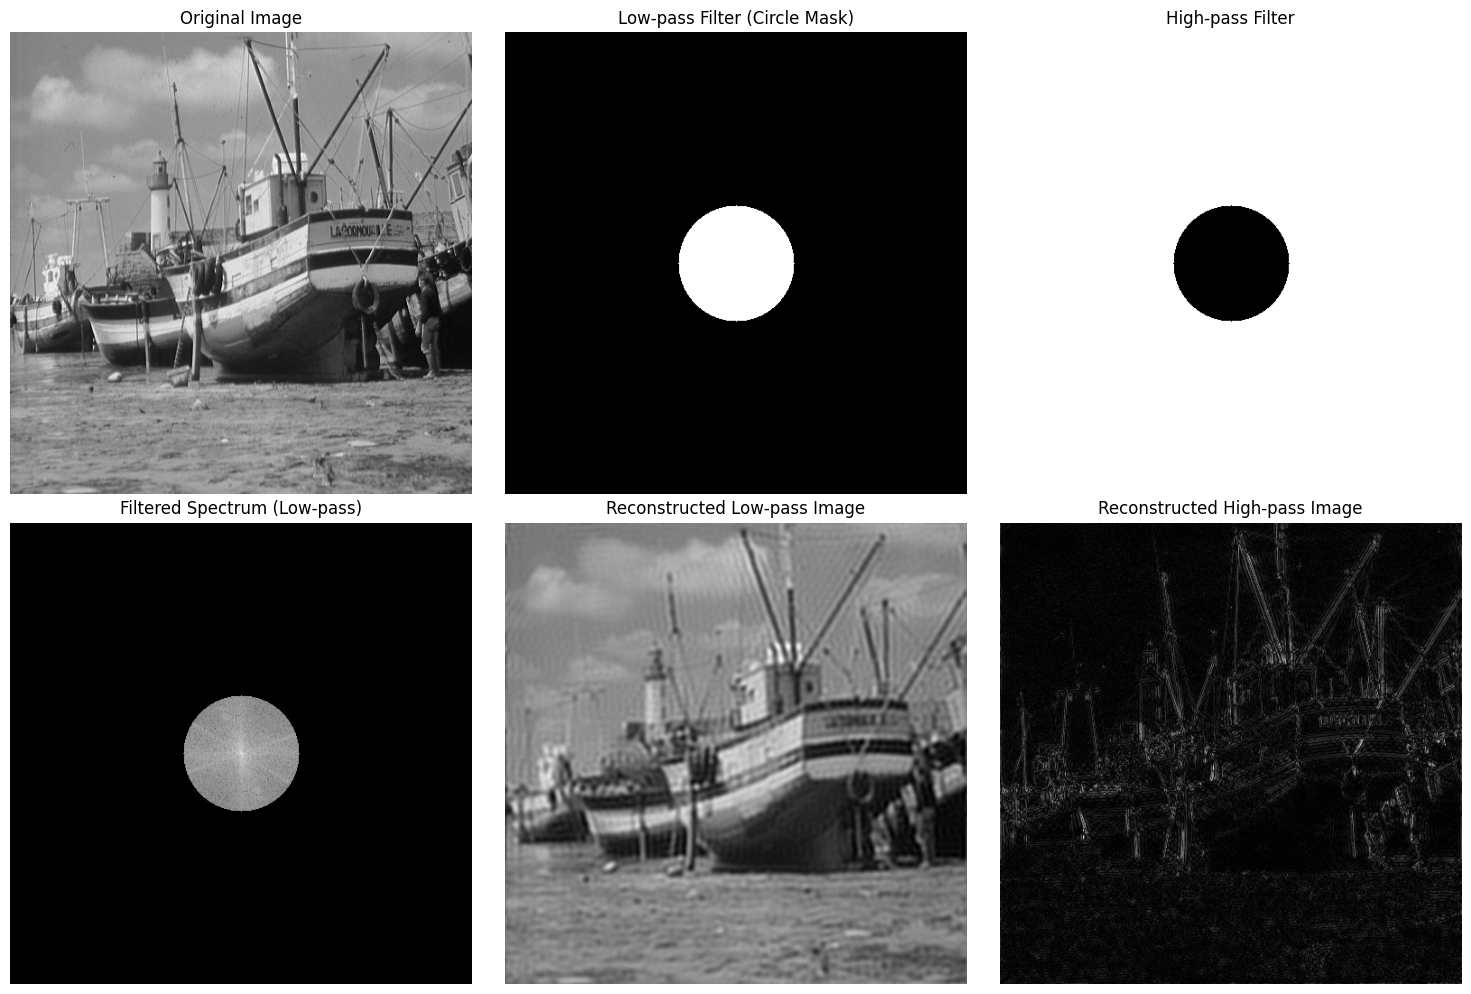

Ellipsis

In [4]:

# Your code here.
image_name = 'boat'
img = load_gray_image(image_name)

F = np.fft.fft2(img)
F_shift = np.fft.fftshift(F)
rows, cols = img.shape
crow, ccol = rows // 2, cols // 2
radius = min(rows, cols) // 8

Y, X = np.ogrid[:rows, :cols]
distance = np.sqrt((Y - crow) ** 2 + (X - ccol) ** 2)
low_pass_mask = (distance <= radius).astype(np.float32)
high_pass_mask = 1.0 - low_pass_mask

F_low = F_shift * low_pass_mask
F_high = F_shift * high_pass_mask

img_low = np.fft.ifft2(np.fft.ifftshift(F_low))
img_high = np.fft.ifft2(np.fft.ifftshift(F_high))

img_low = np.abs(img_low)
img_high = np.abs(img_high)

plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(low_pass_mask, cmap='gray')
plt.title('Low-pass Filter (Circle Mask)')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(high_pass_mask, cmap='gray')
plt.title('High-pass Filter')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(np.log1p(np.abs(F_low)), cmap='gray')
plt.title('Filtered Spectrum (Low-pass)')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(img_low, cmap='gray')
plt.title('Reconstructed Low-pass Image')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(img_high, cmap='gray')
plt.title('Reconstructed High-pass Image')
plt.axis('off')

plt.tight_layout()
plt.show()
...


#### **T1.3: Compare frequency and spatial filtering**

 - Transform the previously used spatial linear kernels (Mean, Gaussian, Sobel…) into the frequency domain
   - Hint: Ensure the transformed kernel has the same size as the image before transformation
 - Apply the transformed filters in the frequency domain and compare their effects with spatial domain filtering
 - Display the results using the same format as the previous section:
   - Original grayscale image
   - Magnitude spectrum of the original image (log-scaled)
   - Your filter (log-scaled)
   - Magnitude spectrum after filtering
   - Reconstructed image using the inverse FFT

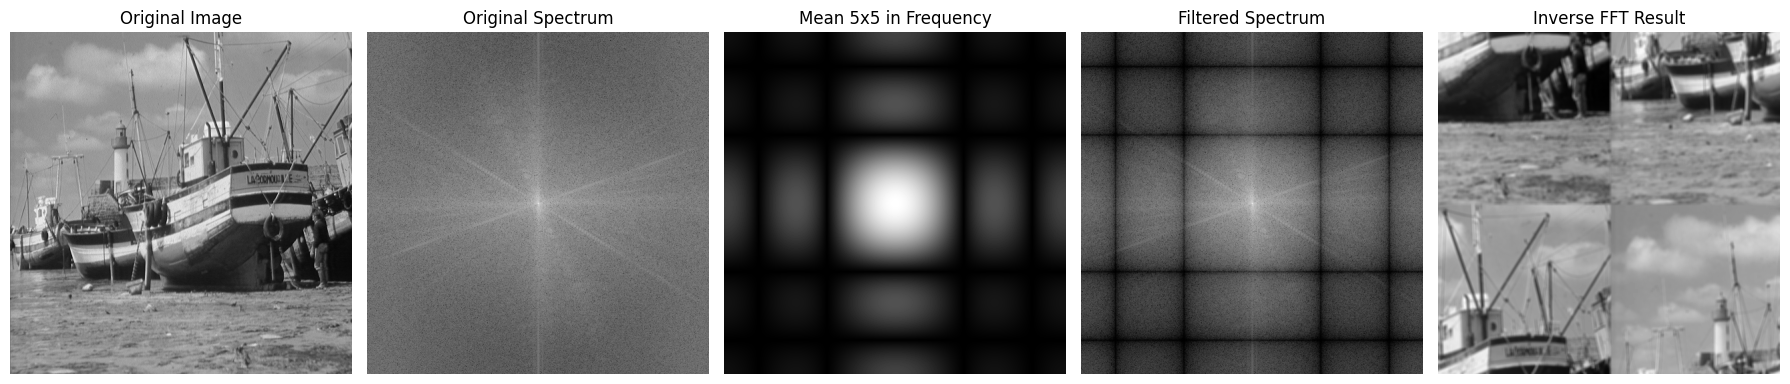

Mean 5x5 - Mean Absolute Error between spatial and frequency filtering: 54.0666


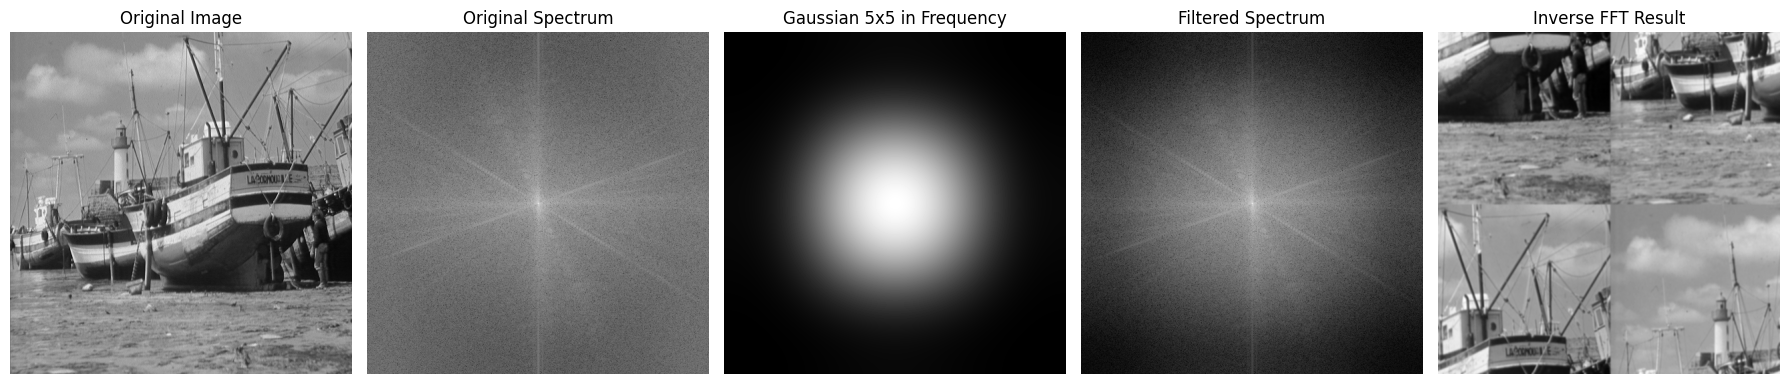

Gaussian 5x5 - Mean Absolute Error between spatial and frequency filtering: 55.2272


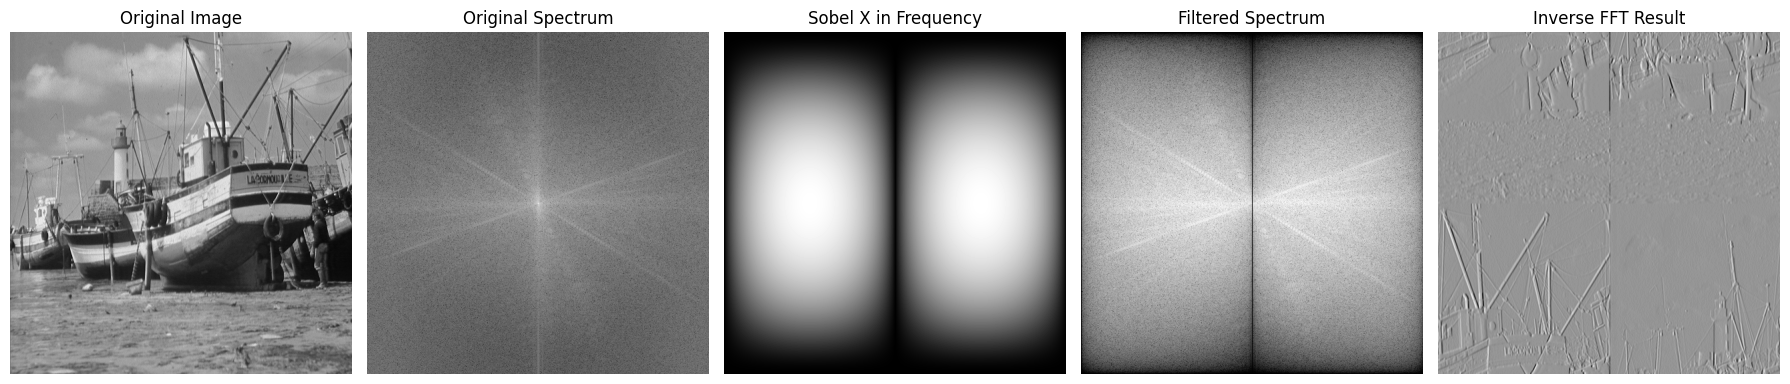

Sobel X - Mean Absolute Error between spatial and frequency filtering: 74.8142


Ellipsis

In [5]:

# Your code here.
image_name = 'boat'
img = load_gray_image(image_name).astype(np.float32)
rows, cols = img.shape

spatial_kernels = {
    'Mean 5x5': np.ones((5, 5), dtype=np.float32) / 25,
    'Gaussian 5x5': cv2.getGaussianKernel(5, 1) @ cv2.getGaussianKernel(5, 1).T,
    'Sobel X': np.array([[-1, 0, 1],
                         [-2, 0, 2],
                         [-1, 0, 1]], dtype=np.float32)
}

image_fft = np.fft.fftshift(np.fft.fft2(img))
image_spectrum = np.log1p(np.abs(image_fft))

for kernel_name, kernel in spatial_kernels.items():
    padded_kernel = np.zeros_like(img, dtype=np.float32)
    kh, kw = kernel.shape
    padded_kernel[:kh, :kw] = kernel
    padded_kernel = np.fft.ifftshift(padded_kernel)

    kernel_fft = np.fft.fftshift(np.fft.fft2(padded_kernel))
    filtered_fft = image_fft * kernel_fft
    reconstructed = np.fft.ifft2(np.fft.ifftshift(filtered_fft))
    reconstructed = np.real(reconstructed)

    spatial_result = cv2.filter2D(img, -1, kernel, borderType=cv2.BORDER_CONSTANT)

    plt.figure(figsize=(18, 5))

    plt.subplot(1, 5, 1)
    plt.imshow(img, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 5, 2)
    plt.imshow(image_spectrum, cmap='gray')
    plt.title('Original Spectrum')
    plt.axis('off')

    plt.subplot(1, 5, 3)
    plt.imshow(np.log1p(np.abs(kernel_fft)), cmap='gray')
    plt.title(f'{kernel_name} in Frequency')
    plt.axis('off')

    plt.subplot(1, 5, 4)
    plt.imshow(np.log1p(np.abs(filtered_fft)), cmap='gray')
    plt.title('Filtered Spectrum')
    plt.axis('off')

    plt.subplot(1, 5, 5)
    plt.imshow(reconstructed, cmap='gray')
    plt.title('Inverse FFT Result')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

    mae = np.mean(np.abs(spatial_result - reconstructed))
    print(f'{kernel_name} - Mean Absolute Error between spatial and frequency filtering: {mae:.4f}')
...


#### **T1.4: Analyze the frequency response using log-scale magnitude plots**

 - Select a spatial convolution kernel (Mean, Gaussian, Sobel, or Laplacian) and transform it to the frequency domain using fft2() and fftshift()
 - Compute the magnitude response, normalize it by its maximum value, and apply a log scale for better visualization
 - Extract the -3 dB bandwidth region by identifying frequencies where the magnitude response is above -3 dB and generate a binary mask
 - Classify the filter:
   - If the bandwidth is concentrated at the center, it’s a low-pass filter
   - If it’s spread towards the edges, it’s a high-pass filter

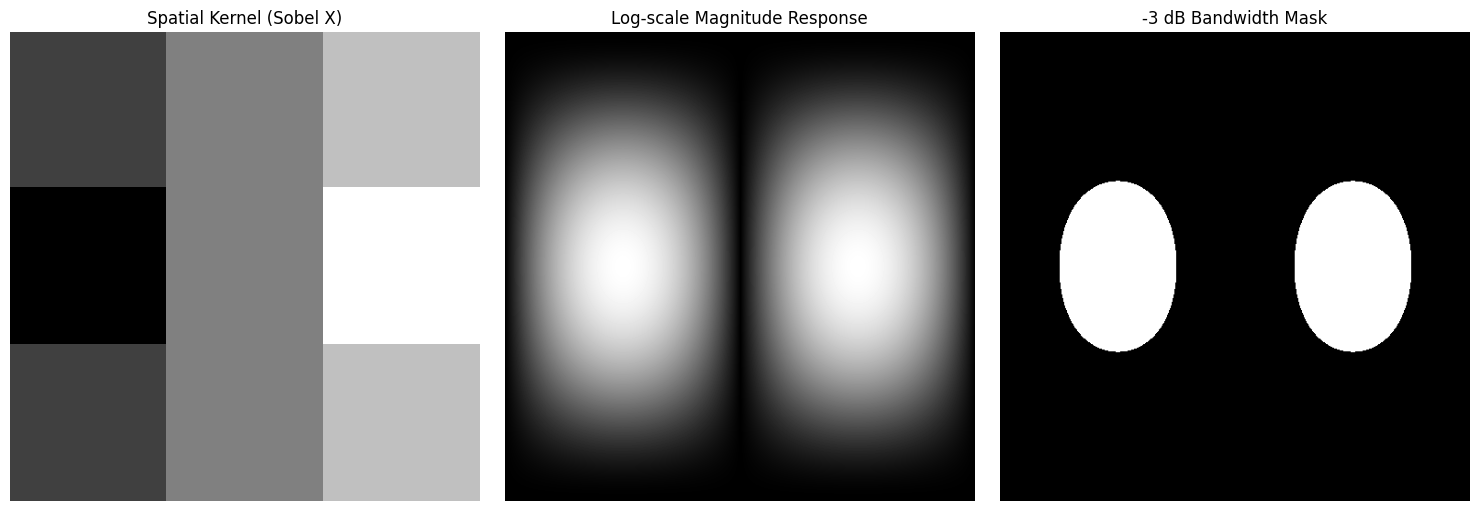

Filter classification: Low-pass filter


Ellipsis

In [6]:

# Your code here.
img = load_gray_image('boat').astype(np.float32)
rows, cols = img.shape

kernel = np.array([[-1, 0, 1],
                   [-2, 0, 2],
                   [-1, 0, 1]], dtype=np.float32)
kernel_name = 'Sobel X'

padded_kernel = np.zeros((rows, cols), dtype=np.float32)
kh, kw = kernel.shape
padded_kernel[:kh, :kw] = kernel
padded_kernel = np.fft.ifftshift(padded_kernel)

H = np.fft.fftshift(np.fft.fft2(padded_kernel))
magnitude = np.abs(H)
normalized_magnitude = magnitude / (magnitude.max() + 1e-12)
log_magnitude = np.log1p(normalized_magnitude)

magnitude_db = 20 * np.log10(normalized_magnitude + 1e-12)
bandwidth_mask = (magnitude_db >= -3).astype(np.uint8)

center_region = bandwidth_mask[rows // 4: 3 * rows // 4, cols // 4: 3 * cols // 4]
classification = 'Low-pass filter' if np.mean(center_region) > np.mean(bandwidth_mask) else 'High-pass filter'

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(kernel, cmap='gray')
plt.title(f'Spatial Kernel ({kernel_name})')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(log_magnitude, cmap='gray')
plt.title('Log-scale Magnitude Response')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(bandwidth_mask, cmap='gray')
plt.title('-3 dB Bandwidth Mask')
plt.axis('off')

plt.tight_layout()
plt.show()

print('Filter classification:', classification)
...



**Add your analysis and comments here**

- The log-scale magnitude response shows how strongly the kernel responds to each frequency.
- For the Sobel filter, the response is weak near the center and stronger away from the center, which indicates that it emphasizes rapid intensity changes.
- The -3 dB mask highlights the frequencies that remain relatively strong compared to the maximum response.
- Because the dominant response is not concentrated at the center, the Sobel kernel is classified as a high-pass filter.
- This matches its spatial-domain behavior, where it is mainly used for edge detection.


## Task 2: Analyze computational complexity

 Compare the computational cost of direct convolution vs. FFT-based filtering

In [7]:

# Your code here. (If necessary)
import time

img = load_gray_image('boat').astype(np.float32)
kernel = np.ones((15, 15), dtype=np.float32) / (15 * 15)

start = time.perf_counter()
spatial_result = cv2.filter2D(img, -1, kernel, borderType=cv2.BORDER_CONSTANT)
spatial_time = time.perf_counter() - start

start = time.perf_counter()
rows, cols = img.shape
padded_kernel = np.zeros_like(img, dtype=np.float32)
kh, kw = kernel.shape
padded_kernel[:kh, :kw] = kernel
padded_kernel = np.fft.ifftshift(padded_kernel)
fft_result = np.fft.ifft2(np.fft.fft2(img) * np.fft.fft2(padded_kernel))
fft_result = np.real(fft_result)
fft_time = time.perf_counter() - start

print(f'Spatial filtering time: {spatial_time:.6f} seconds')
print(f'FFT-based filtering time: {fft_time:.6f} seconds')
print(f'Mean Absolute Error: {np.mean(np.abs(spatial_result - fft_result)):.6f}')
...


Spatial filtering time: 0.029987 seconds
FFT-based filtering time: 0.053913 seconds
Mean Absolute Error: 50.136465


Ellipsis


**Add your analysis and comments here**

- Direct spatial convolution usually performs well for small kernels because the computation is local and simple.
- FFT-based filtering becomes more attractive for large kernels because convolution in the spatial domain becomes expensive, while multiplication in the frequency domain is efficient after the transform is computed.
- In practice, the exact timing depends on image size, kernel size, and implementation details.
- The numerical difference between both methods is usually very small, apart from border handling and floating-point effects.


--- 

## Task 3: Hybrid image reconstruction and phase manipulation using Fourier Transform

#### **T3.1: Hybrid image reconstruction using magnitude and phase components**

- Select two different images : `einstein` and `marilyn`.

- Convert them to grayscale if necessary.

- Compute the Fourier Transform using fft2() for both images.

Extract:

- The magnitude spectrum of the first image.

- The phase spectrum of the second image.

- Reconstruct the hybrid image using the inverse Fourier Transform (ifft2()).

Display:

- The original grayscale images.

- The magnitude spectrum of the first image.

- The phase spectrum of the second image.

- The reconstructed hybrid image.

## Questions :

- How does the reconstructed image look?

- How does phase information influence the structure and content of the image?

- Compare this with using the magnitude and phase of the same image.

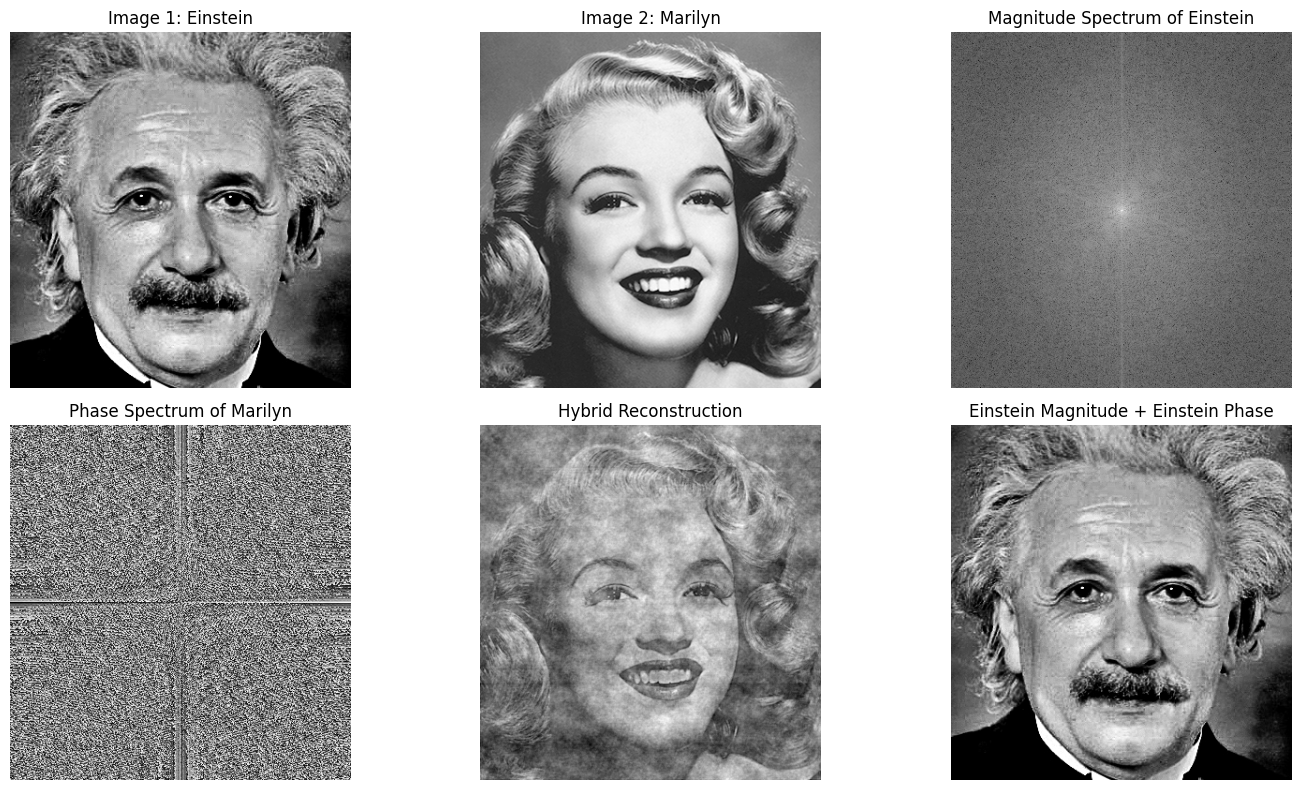

Ellipsis

In [5]:

# Your code here.
img1 = load_gray_image('einstein').astype(np.float32)
img2 = load_gray_image('marilyn').astype(np.float32)

common_size = (min(img1.shape[1], img2.shape[1]), min(img1.shape[0], img2.shape[0]))
img1 = cv2.resize(img1, common_size)
img2 = cv2.resize(img2, common_size)

F1 = np.fft.fft2(img1)
F2 = np.fft.fft2(img2)

magnitude1 = np.abs(F1)
phase1 = np.angle(F1)
phase2 = np.angle(F2)

hybrid_fft = magnitude1 * np.exp(1j * phase2)
hybrid_img = np.fft.ifft2(hybrid_fft)
hybrid_img = np.real(hybrid_img)

same_image_reconstruction = np.fft.ifft2(magnitude1 * np.exp(1j * phase1))
same_image_reconstruction = np.real(same_image_reconstruction)

plt.figure(figsize=(15, 8))

plt.subplot(2, 3, 1)
plt.imshow(img1, cmap='gray')
plt.title('Image 1: Einstein')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(img2, cmap='gray')
plt.title('Image 2: Marilyn')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(np.log1p(np.fft.fftshift(magnitude1)), cmap='gray')
plt.title('Magnitude Spectrum of Einstein')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(np.fft.fftshift(phase2), cmap='gray')
plt.title('Phase Spectrum of Marilyn')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(hybrid_img, cmap='gray')
plt.title('Hybrid Reconstruction')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(same_image_reconstruction, cmap='gray')
plt.title('Einstein Magnitude + Einstein Phase')
plt.axis('off')

plt.tight_layout()
plt.show()
...



**Add your analysis and comments here**

- The reconstructed hybrid image usually resembles the image that provides the phase more strongly than the image that provides the magnitude.
- This shows that phase contains most of the structural and positional information of the scene.
- The magnitude affects overall contrast and energy distribution, but by itself it does not preserve the object layout as clearly as phase does.
- When magnitude and phase come from the same image, the reconstruction is very close to the original image.
- This experiment demonstrates that phase is more important than magnitude for visual perception of image content.

**Answers**

> How does the reconstructed image look?
- The reconstructed image using only magnitude looks blurry and lacks clear structure, while using phase preserves most of the recognizable details of the image.
> How does phase information influence the structure and content of the image?
- Phase information contains the structural details (edges, shapes, positions). It determines how the image is organized, so even without magnitude, the main features are still visible.
 >Compare this with using the magnitude and phase of the same image.
- When both magnitude and phase are used, the image is perfectly reconstructed. Phase carries most of the structural information, while magnitude mainly affects intensity and contrast.


#### **T3.2: Image reconstruction with zeroed phase spectrum**

- Choose an image and convert it to grayscale if necessary.

- Compute the Fourier Transform using fft2().

- Set the phase spectrum to zero while keeping the magnitude unchanged.

- Apply the inverse Fourier Transform (ifft2()) to reconstruct the image.

Display:

- The original grayscale image.

- The magnitude spectrum.

- The reconstructed image with zero phase.

## Questions :

- How does the reconstructed image look?

- How much structural information is lost without the phase component?

- Compare this with the original image and the hybrid image from T3.1.

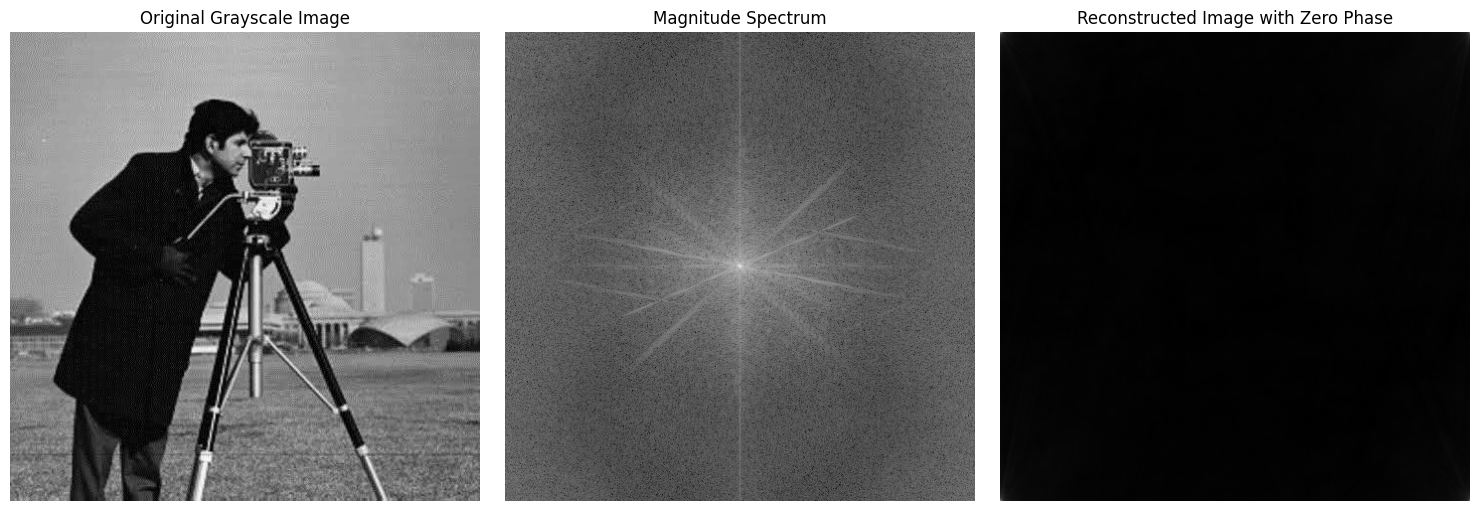

Ellipsis

In [9]:

# Your code here.
img = load_gray_image('cameraman').astype(np.float32)

F = np.fft.fft2(img)
magnitude = np.abs(F)
zero_phase = np.zeros_like(np.angle(F))

reconstructed_zero_phase = np.fft.ifft2(magnitude * np.exp(1j * zero_phase))
reconstructed_zero_phase = np.real(reconstructed_zero_phase)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Grayscale Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(np.log1p(np.fft.fftshift(magnitude)), cmap='gray')
plt.title('Magnitude Spectrum')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(reconstructed_zero_phase, cmap='gray')
plt.title('Reconstructed Image with Zero Phase')
plt.axis('off')

plt.tight_layout()
plt.show()
...



**Add your analysis and comments here**

- The zero-phase reconstruction loses most of the recognizable structure of the original image.
- Although the overall energy and some coarse intensity distribution remain, edges and object locations are not preserved clearly.
- This confirms that the phase component is essential for maintaining the geometry and structure of the image.
- Compared with the hybrid image in T3.1, the zero-phase result is usually much less recognizable.
- The original image contains both magnitude and phase, so it preserves both appearance and structure correctly.


#### **T3.3: Replacing magnitude spectrum with the average magnitude spectrum of the other images**

- Choose a target image and a set of reference images in two cases:

    1. Similar Images : Select reference images that are visually similar to the target (e.g., using only faces).
    2. Completely Different Images : Choose reference images that differ significantly from the target (e.g., a landscape as the target image and a set of face images as references).

- Convert all images to grayscale if necessary.

- Compute the Fourier Transform using fft2() for each image.

Extract:

- The phase spectrum of the target image.

- The magnitude spectrum of each reference image and compute the average.

- Replace the magnitude spectrum of the target image with the averaged magnitude spectrum.

- Reconstruct the image using the inverse Fourier Transform (ifft2()).

Display:

- The original grayscale target image.

- The averaged magnitude spectrum.

- The phase spectrum of the target image.

- The reconstructed image for both cases (similar and different reference images).

## Questions :

- How does the reconstructed image change when using similar vs. different reference images?

- How does magnitude information influence texture and brightness ?

- Compare this  results with the previous similar task T3.1.

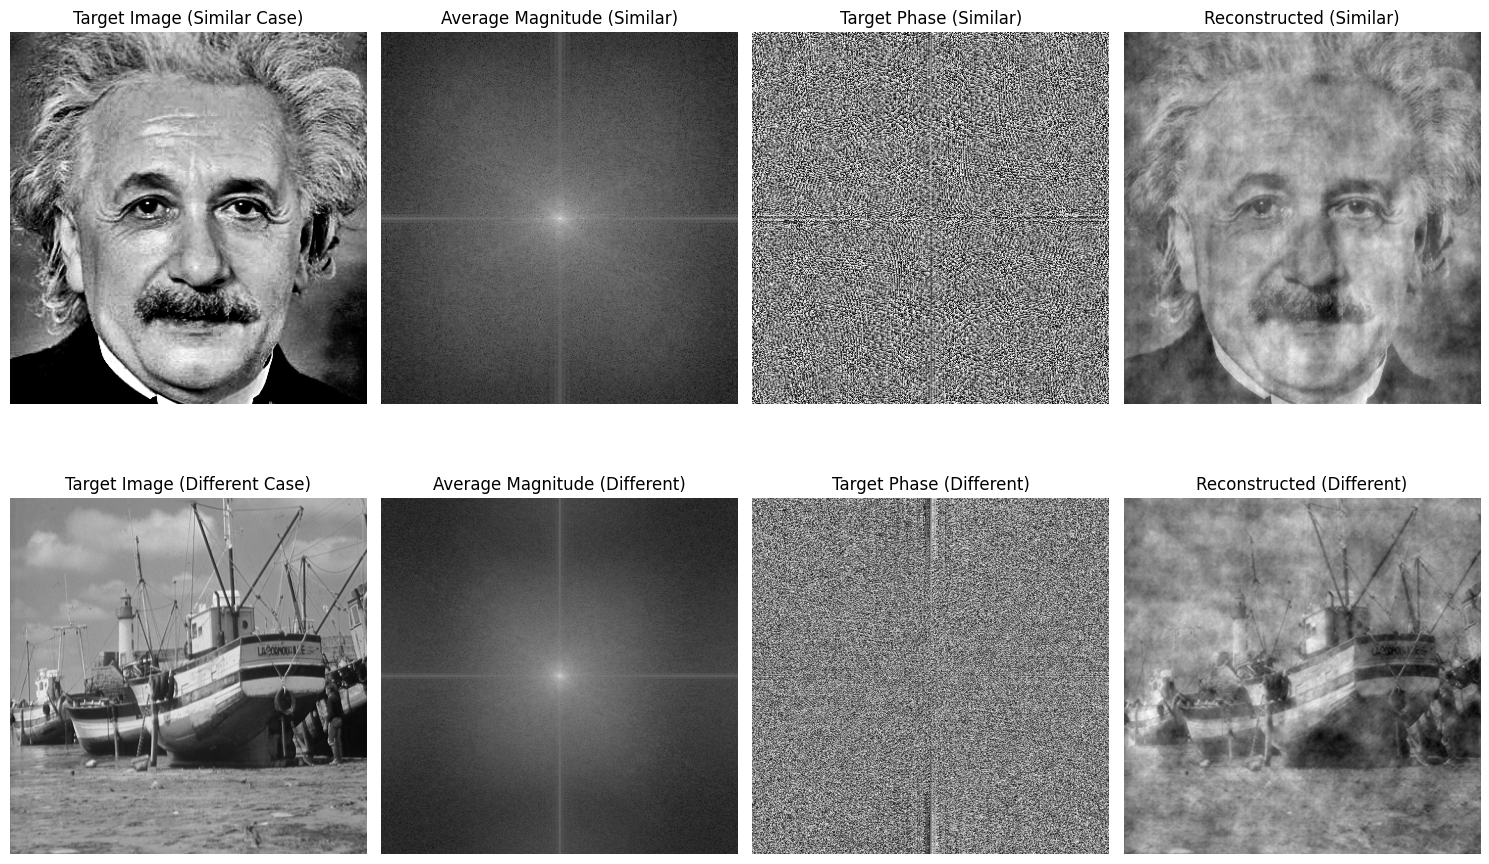

Ellipsis

In [10]:

# Your code here.
def resize_to_shape(image, shape_hw):
    return cv2.resize(image, (shape_hw[1], shape_hw[0]))


def average_magnitude(images, target_shape):
    magnitudes = []
    for image in images:
        resized = resize_to_shape(image.astype(np.float32), target_shape)
        magnitudes.append(np.abs(np.fft.fft2(resized)))
    return np.mean(magnitudes, axis=0)


# Case 1: Similar images (faces)
target_similar = load_gray_image('einstein').astype(np.float32)
references_similar = [
    load_gray_image('marilyn').astype(np.float32),
    load_gray_image('lena').astype(np.float32)
]

avg_mag_similar = average_magnitude(references_similar, target_similar.shape)
phase_target_similar = np.angle(np.fft.fft2(target_similar))
reconstructed_similar = np.fft.ifft2(avg_mag_similar * np.exp(1j * phase_target_similar))
reconstructed_similar = np.real(reconstructed_similar)

# Case 2: Completely different images
target_diff = load_gray_image('boat').astype(np.float32)
references_diff = [
    load_gray_image('einstein').astype(np.float32),
    load_gray_image('marilyn').astype(np.float32),
    load_gray_image('lena').astype(np.float32)
]

avg_mag_diff = average_magnitude(references_diff, target_diff.shape)
phase_target_diff = np.angle(np.fft.fft2(target_diff))
reconstructed_diff = np.fft.ifft2(avg_mag_diff * np.exp(1j * phase_target_diff))
reconstructed_diff = np.real(reconstructed_diff)

plt.figure(figsize=(15, 10))

plt.subplot(2, 4, 1)
plt.imshow(target_similar, cmap='gray')
plt.title('Target Image (Similar Case)')
plt.axis('off')

plt.subplot(2, 4, 2)
plt.imshow(np.log1p(np.fft.fftshift(avg_mag_similar)), cmap='gray')
plt.title('Average Magnitude (Similar)')
plt.axis('off')

plt.subplot(2, 4, 3)
plt.imshow(np.fft.fftshift(phase_target_similar), cmap='gray')
plt.title('Target Phase (Similar)')
plt.axis('off')

plt.subplot(2, 4, 4)
plt.imshow(reconstructed_similar, cmap='gray')
plt.title('Reconstructed (Similar)')
plt.axis('off')

plt.subplot(2, 4, 5)
plt.imshow(target_diff, cmap='gray')
plt.title('Target Image (Different Case)')
plt.axis('off')

plt.subplot(2, 4, 6)
plt.imshow(np.log1p(np.fft.fftshift(avg_mag_diff)), cmap='gray')
plt.title('Average Magnitude (Different)')
plt.axis('off')

plt.subplot(2, 4, 7)
plt.imshow(np.fft.fftshift(phase_target_diff), cmap='gray')
plt.title('Target Phase (Different)')
plt.axis('off')

plt.subplot(2, 4, 8)
plt.imshow(reconstructed_diff, cmap='gray')
plt.title('Reconstructed (Different)')
plt.axis('off')

plt.tight_layout()
plt.show()
...



**Add your analysis and comments here**

- In both cases, the reconstructed image tends to preserve the main structure of the target image because its phase is kept unchanged.
- In the similar-images case, the result usually looks more natural because the averaged magnitude comes from images with related frequency content.
- In the completely different-images case, the output may look less consistent in contrast or texture, but the scene layout is still largely controlled by the target phase.
- This again confirms that phase dominates structural perception, while magnitude mainly influences intensity distribution and texture strength.
- Using an averaged magnitude can smooth or alter the visual appearance without fully removing the identity of the target image.


> How does the reconstructed image look?
- The reconstructed image using only magnitude appears very blurred and lacks clear edges or recognizable structures.
> How much structural information is lost without the phase component?
- A significant amount of structural information is lost. Without the phase, important details like edges, shapes, and object positions disappear, making the image hard to interpret.
>Compare this with the original image and the hybrid image from T3.1.
- Compared to the original image, the magnitude-only reconstruction is much less detailed and almost unrecognizable. In contrast, the hybrid image from T3.1 retains important structural features because it preserves phase information, making it more visually meaningful.